In [6]:
import numpy as np
import tensorflow as tf

import os
import zipfile

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

from scipy.interpolate import interp1d
from scipy import signal
from scipy.integrate import solve_ivp

from sklearn.model_selection import train_test_split

# Make sure interactive plotting is enabled
%matplotlib widget

# Function to load maximum displacement and elongation

In [7]:


def extract_x_s_max(thickness: str, f_: int, plot: bool = False, return_x_sa_max: bool = False) -> float:
    # thickness = "1mm6_12kg6"
    # thickness = "6mm4_12kg6"

    # Path to your zip file
    zip_file_path = r"C:\TRABAJO\CONICET\datasets\protection\\"
    zip_file_path += thickness + fr"\\F_{f_}_kN.zip"


    # Define the prefixes to organize files
    prefixes = ["flecha_chapa", "flecha_losa", "presion_chapa", "presion_losa", "elongacion"]


    # Extraction directory
    output_dir = r'C:\Users\joses\Mi unidad\TRABAJO\48_FG_protection\TRABAJO\fgp_optimizer\optimization_simple_plastic\full_simulation_data\iter1_mean_press'


    # Ensure the output directory exists
    os.makedirs(output_dir, exist_ok=True)

    # Extract and organize files
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        for file_name in zip_ref.namelist():
            # Check if the file starts with any of the prefixes
            for prefix in prefixes:
                if file_name.startswith(prefix):
                    # Create the subfolder if it doesn't exist
                    subfolder_path = os.path.join(output_dir, prefix)
                    os.makedirs(subfolder_path, exist_ok=True)
                    
                    # Extract the file to the appropriate subfolder
                    source = zip_ref.open(file_name)
                    target_path = os.path.join(subfolder_path, os.path.basename(file_name))
                    with open(target_path, "wb") as target:
                        target.write(source.read())
                    break  # Stop checking other prefixes once a match is found


    # Extract nodos.txt
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        source = zip_ref.open('nodos.txt')
        with open(os.path.join(output_dir, 'nodos.txt'), 'wb') as target:
            target.write(source.read())

    def load_multiple_records(file_path):
        with open(file_path, 'r') as file:
            lines = file.readlines()
        
        records = []
        current_record = []
        header = lines[0].strip()  # Assuming the first line is the header
        
        for line in lines:
            if line.strip() == header:
                if current_record:
                    records.append(np.array(current_record, dtype=float))
                    current_record = []
            else:
                current_record.append([float(value) for value in line.split()])
        
        if current_record:  # Add the last record if the file doesn't end with a header line
            records.append(np.array(current_record, dtype=float))
        
        return records


    # Folder path where the files are stored
    folder_path = output_dir
    folder_path_presion_losa = os.path.join(folder_path, 'presion_losa')  # N/cm2
    folder_path_presion_chapa = os.path.join(folder_path, 'presion_chapa') # MPa = N/mm2
    folder_path_flecha_losa = os.path.join(folder_path, 'flecha_losa')
    folder_path_flecha_chapa = os.path.join(folder_path, 'flecha_chapa')
    folder_path_elongacion = os.path.join(folder_path, 'elongacion')

    presion_losa_scale = 1/100

    # Dictionary to store the data for each node
    data_dicts = {}
    node_ids = []
    nodes = np.loadtxt(os.path.join(folder_path, 'nodos.txt'))[:, 1:]

    # Custom converters for handling invalid entries 
    def safe_convert(val): 
        try: 
            return float(val) 
        except ValueError: 
            return np.nan # or any default value

    converters = {1: safe_convert} # Apply safe_convert to the second column

    # Iterate over each file in the folder
    for filename in os.listdir(folder_path_presion_losa):
        if filename.startswith('presion_losa'):
            # Extract the node ID from the filename
            node_id = filename.split('node')[-1]
            node_ids.append(node_id)
            
            # Construct the full file path
            file_path_presion_losa = os.path.join(folder_path_presion_losa, filename)
            if filename.startswith('presion_losa_c'):
                file_path_flecha_losa = os.path.join(folder_path_flecha_losa, filename.replace('presion_losa_c_node', 'flecha_losa_node'))
                file_path_elong = os.path.join(folder_path_elongacion, filename.replace('presion_losa_c_node', 'elongacion_node'))
            elif filename.startswith('presion_losa_f'):
                file_path_flecha_losa = os.path.join(folder_path_flecha_losa, filename.replace('presion_losa_f_node', 'flecha_losa_node'))
                file_path_elong = os.path.join(folder_path_elongacion, filename.replace('presion_losa_f_node', 'elongacion_node'))

            # Load the data, skipping the first line
            data = load_multiple_records(file_path_presion_losa)
            
            # Load displacements and their time vector
            time_disp = np.loadtxt(file_path_flecha_losa, skiprows=1, converters=converters)
            time_elong = np.loadtxt(file_path_elong, skiprows=1, converters=converters)

            # Store the time and pressure data in the dictionary under the node_id
            if node_id in data_dicts.keys():
                data_dicts[node_id] = {
                    'time': data[0][:, 0],
                    'pressure': data_dicts[node_id]['pressure'] - np.mean(np.array(data), axis=0)[:,1] * presion_losa_scale,
                    'displacement': np.interp(data[0][:, 0], time_disp[:, 0], time_disp[:, 1]), 
                    'elongation': time_elong[:, 1], 
                    'coordinates': nodes[int(node_id)]
                }
            else:
                data_dicts[node_id] = {
                    'time': data[0][:, 0],
                    'pressure': - np.mean(np.array(data), axis=0)[:,1] * presion_losa_scale,
                    'displacement': np.interp(data[0][:, 0], time_disp[:, 0], time_disp[:, 1]), 
                    'elongation': time_elong[:, 1], 
                    'coordinates': nodes[int(node_id)]
                }

    if plot:
        # Extraction of load pressure
        # Dictionary to store the data for each node
        data_dicts_load = {}
        node_ids_load = []
        # Iterate over each file in the folder
        for filename in os.listdir(folder_path_presion_chapa):
            if filename.startswith('presion_chapa_node'):
                # Extract the node ID from the filename
                node_id = filename.split('node')[-1]
                node_ids_load.append(node_id)
                
                # Construct the full file path
                file_path_presion_chapa = os.path.join(folder_path_presion_chapa, filename)
                file_path_flecha_chapa = os.path.join(folder_path_flecha_chapa, filename.replace('presion_chapa_node ', 'flecha_chapa_node'))
                
                # Load the data, skipping the first line
                data_load = load_multiple_records(file_path_presion_chapa)
                time_disp = np.loadtxt(file_path_flecha_chapa, skiprows=1, converters=converters)

                # Store the time and pressure data in the dictionary under the node_id
                data_dicts_load[node_id] = {
                    'time': data_load[0][:, 0],
                    'pressure': -np.mean(np.array(data_load), axis=0)[:,1],
                    'coordinates': nodes[int(node_id)],
                    'displacement': np.interp(data_load[0][:, 0], time_disp[:, 0], time_disp[:, 1]), 
                }

        fig1, ax1 = plt.subplots(3, 1, sharex='col')
        ax1 = ax1.flatten()

        n_rows = 150
        n_rows_load = 10*n_rows
        for node_id in node_ids_load:
            ax1[0].plot(data_dicts_load[node_id]['time'][:n_rows_load], data_dicts_load[node_id]['pressure'][:n_rows_load])
            ax1[0].set_ylabel('load pressure (MPa)')

        for node_id in node_ids:
            ax1[1].plot(data_dicts[node_id]['time'][:n_rows], data_dicts[node_id]['pressure'][:n_rows])
            ax1[1].set_ylabel('pressure (MPa)')
            ax1[2].plot(data_dicts[node_id]['time'][:n_rows], data_dicts[node_id]['displacement'][:n_rows])
            ax1[2].set_ylabel('displacement (mm)')
            ax1[2].set_xlabel('time (s)')
        plt.show()

    x_s_max_hf = np.abs(1e-3*np.min(np.array([data_dicts[node_id]['displacement'] for node_id in node_ids]).ravel()))

    if return_x_sa_max:
        x_sa_max_hf = np.abs(1e-3*np.min(np.array([data_dicts[node_id]['elongation'] for node_id in node_ids]).ravel()))
        print(f"x_s_max_hf = {x_s_max_hf}  # m, x_sa_max_hf = {x_sa_max_hf}  # m")
        return x_s_max_hf, x_sa_max_hf
    else:
        print(f"x_s_max_hf = {x_s_max_hf}  # m")
        return x_s_max_hf



# Analyze data

In [8]:
f_list = list(np.arange(5,200,5).astype(int))
# f_list.remove(35)
f_arr = np.array(f_list)
f_arr

array([  5,  10,  15,  20,  25,  30,  35,  40,  45,  50,  55,  60,  65,
        70,  75,  80,  85,  90,  95, 100, 105, 110, 115, 120, 125, 130,
       135, 140, 145, 150, 155, 160, 165, 170, 175, 180, 185, 190, 195])

In [9]:
x_s_max_1mm6_12kg6 = []
x_sa_max_1mm6_12kg6 = []

for f_ in f_arr:
    x_s_max_hf, x_sa_max_hf = extract_x_s_max(thickness="1mm6_12kg6_ok", f_=f_, return_x_sa_max=True)
    x_s_max_1mm6_12kg6.append(x_s_max_hf)
    x_sa_max_1mm6_12kg6.append(x_sa_max_hf)

x_s_max_1mm6_12kg6 = np.array(x_s_max_1mm6_12kg6)
x_sa_max_1mm6_12kg6 = np.array(x_sa_max_1mm6_12kg6)

x_s_max_hf = 0.03929445869963943  # m, x_sa_max_hf = 0.10077799988  # m
x_s_max_hf = 0.03471568681406448  # m, x_sa_max_hf = 0.1005719986  # m
x_s_max_hf = 0.033171989380711225  # m, x_sa_max_hf = 0.10086100006  # m
x_s_max_hf = 0.029201505622228754  # m, x_sa_max_hf = 0.10055500031  # m
x_s_max_hf = 0.027805950230807785  # m, x_sa_max_hf = 0.10064399719  # m
x_s_max_hf = 0.024661752715946315  # m, x_sa_max_hf = 0.10053099823  # m
x_s_max_hf = 0.020728704424212766  # m, x_sa_max_hf = 0.10059700012  # m
x_s_max_hf = 0.018389831342494507  # m, x_sa_max_hf = 0.10048999786  # m
x_s_max_hf = 0.016654481919785538  # m, x_sa_max_hf = 0.10056800079  # m
x_s_max_hf = 0.01432790364903594  # m, x_sa_max_hf = 0.10051499939  # m
x_s_max_hf = 0.012632195198611014  # m, x_sa_max_hf = 0.10034500122000001  # m
x_s_max_hf = 0.010597115538300585  # m, x_sa_max_hf = 0.10036599731  # m
x_s_max_hf = 0.009753609661956606  # m, x_sa_max_hf = 0.10034100342  # m
x_s_max_hf = 0.009258085253805127  # m, x_sa_max_

In [10]:
x_s_max_6mm4_12kg6 = []
x_sa_max_6mm4_12kg6 = []

for f_ in f_arr:
    x_s_max_hf, x_sa_max_hf = extract_x_s_max(thickness="6mm4_12kg6", f_=f_, return_x_sa_max=True)
    x_s_max_6mm4_12kg6.append(x_s_max_hf)
    x_sa_max_6mm4_12kg6.append(x_sa_max_hf)

x_s_max_6mm4_12kg6 = np.array(x_s_max_6mm4_12kg6)
x_sa_max_6mm4_12kg6 = np.array(x_sa_max_6mm4_12kg6)

x_s_max_hf = 0.03140333037516519  # m, x_sa_max_hf = 0.10077100372  # m
x_s_max_hf = 0.0271250209744368  # m, x_sa_max_hf = 0.10050900269  # m
x_s_max_hf = 0.021286691665999998  # m, x_sa_max_hf = 0.10045400238  # m
x_s_max_hf = 0.02017886520881414  # m, x_sa_max_hf = 0.10048699951000001  # m
x_s_max_hf = 0.017003290077271135  # m, x_sa_max_hf = 0.10040799713  # m
x_s_max_hf = 0.015413553224633378  # m, x_sa_max_hf = 0.10052799988  # m
x_s_max_hf = 0.014136294398749234  # m, x_sa_max_hf = 0.100375  # m
x_s_max_hf = 0.012470127867604439  # m, x_sa_max_hf = 0.10021099854000001  # m
x_s_max_hf = 0.011958802953869571  # m, x_sa_max_hf = 0.10024299621999999  # m
x_s_max_hf = 0.008854738229666988  # m, x_sa_max_hf = 0.10024700165  # m
x_s_max_hf = 0.007544296866829204  # m, x_sa_max_hf = 0.10028800201  # m
x_s_max_hf = 0.006647944016838983  # m, x_sa_max_hf = 0.10029799652  # m
x_s_max_hf = 0.0058325801086712556  # m, x_sa_max_hf = 0.10025800323  # m
x_s_max_hf = 0.00559588389466314  # m, x_

In [106]:
def plot_optimality(f_eq_optimized_1mm6, f_eq_optimized_6mm4, x_s_max_1mm6_12kg6, x_s_max_6mm4_12kg6, 
                    x_sa_max_1mm6_12kg6, x_sa_max_6mm4_12kg6, x_s_max_np, filename):
    x_s_max_1mm6_12kg6_optimized = x_s_max_1mm6_12kg6[np.argmin(np.abs(f_eq_optimized_1mm6 - f_arr))]
    x_s_max_6mm4_12kg6_optimized = x_s_max_6mm4_12kg6[np.argmin(np.abs(f_eq_optimized_1mm6 - f_arr))]

    f_eq_optimum_1mm6 = f_arr[np.argmin(np.abs(x_s_max_1mm6_12kg6))]
    f_eq_optimum_6mm4 = f_arr[np.argmin(np.abs(x_s_max_6mm4_12kg6))]
    x_s_max_1mm6_12kg6_optimum = np.min(np.abs(x_s_max_1mm6_12kg6))
    x_s_max_6mm4_12kg6_optimum = np.min(np.abs(x_s_max_6mm4_12kg6))

    fig, ax = plt.subplots(2, 1, sharex='col', figsize=(6, 4))
    def plot_subplot(ax_, f_arr, x_s_max_1mm6_12kg6, x_s_max_6mm4_12kg6, ylim, ylabel, hlines=True, legend=True, xlabel=True):
        
        if not legend:
            ax_.hlines(-1, 0, 200, colors=['k'], label='w/o protect.')
            ax_.legend(loc='best')

        ax_.minorticks_on()
        ax_.minorticks_on()
        ax_.plot(f_arr, x_s_max_1mm6_12kg6, color='b', label='thickn. = 1.6 mm')
        ax_.plot(f_arr, x_s_max_6mm4_12kg6, color='r', label='thickn. = 6.4 mm')

        ax_.vlines(f_eq_optimized_1mm6, 0, x_s_max_1mm6_12kg6_optimized if hlines else 1., colors=['b'], linestyles=['dashed'], label='this work')
        ax_.vlines(f_eq_optimized_6mm4, 0, x_s_max_6mm4_12kg6_optimized if hlines else 1., colors=['r'], linestyles=['dashed'], label='this work')
        ax_.vlines(f_eq_optimum_1mm6, 0, x_s_max_1mm6_12kg6_optimum if hlines else 1., colors=['b'], linestyles=['dotted'], alpha=[0.5], label='brute force')
        ax_.vlines(f_eq_optimum_6mm4, 0, x_s_max_6mm4_12kg6_optimum if hlines else 1., colors=['r'], linestyles=['dotted'], alpha=[0.5], label='brute force')

        if xlabel:
            ax_.set_xlabel(r'$f_{eq}$ (kN)')
        ax_.set_ylabel(ylabel)
        ax_.set_xlim([0, f_arr[-1]])
        ax_.set_ylim(ylim)
        # ax_.set_title('high-fidelity simulations')
        if legend:
            ax_.legend(loc='lower left', ncol=3)
        
        if hlines:
            ax_.hlines(x_s_max_np, 0, 200, colors=['k'], label='w/o protect.')
            ax_.hlines(x_s_max_1mm6_12kg6_optimized, 0, f_eq_optimized_1mm6, colors=['b'], linestyles=['dashed'])
            ax_.hlines(x_s_max_6mm4_12kg6_optimized, 0, f_eq_optimized_6mm4, colors=['r'], linestyles=['dashed'])
            ax_.hlines(x_s_max_1mm6_12kg6_optimum, 0, f_eq_optimum_1mm6, colors=['b'], linestyles=['dotted'], alpha=[0.5])
            ax_.hlines(x_s_max_6mm4_12kg6_optimum, 0, f_eq_optimum_6mm4, colors=['r'], linestyles=['dotted'], alpha=[0.5])
    
    plot_subplot(ax[0], f_arr, x_s_max_1mm6_12kg6, x_s_max_6mm4_12kg6, [0, .03], xlabel=False, legend=False, ylabel=r'$\max_{t}{|x_s(t)|}$')
    plot_subplot(ax[1], f_arr, x_sa_max_1mm6_12kg6, x_sa_max_6mm4_12kg6, [0, .12], hlines=False, legend=True, ylabel=r'-$\min_{t}{x_{sa}(t)}$')
    plt.tight_layout()

    fig.savefig(filename, bbox_inches='tight')
    plt.show()

# Work equivalence fs


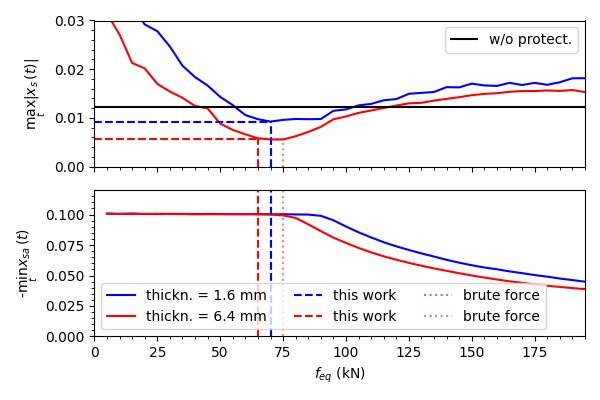

In [107]:
f_eq_optimized_1mm6 = 70.0
f_eq_optimized_6mm4 = 65.0
x_s_max_np = 0.012242351532000002
filename = 'optimality.pdf'
plot_optimality(f_eq_optimized_1mm6, f_eq_optimized_6mm4, 
                x_s_max_1mm6_12kg6, x_s_max_6mm4_12kg6, 
                x_sa_max_1mm6_12kg6, x_sa_max_6mm4_12kg6,
                x_s_max_np, filename)